In [2]:
import os
os.chdir('..')
print("Working from:", os.getcwd())

Working from: C:\Users\Abhijeet\PhD_MAML_AE


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import torch
from sklearn.preprocessing import MinMaxScaler

pd.set_option('display.max_columns', 20)
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

print("✅ All libraries imported successfully")
print(f"PyTorch version : {torch.__version__}")
print(f"Working from    : {os.getcwd()}")

✅ All libraries imported successfully
PyTorch version : 2.12.1+cpu
Working from    : C:\Users\Abhijeet\PhD_MAML_AE


In [4]:
TRAIN_PATH = "data/raw/train/"
TEST_PATH  = "data/raw/test/"
LABEL_PATH = "data/raw/labeled_anomalies.csv"

labels_df = pd.read_csv(LABEL_PATH)

smap_channels = labels_df[labels_df['spacecraft']=='SMAP']['chan_id'].tolist()
msl_channels  = labels_df[labels_df['spacecraft']=='MSL']['chan_id'].tolist()

print(f"Total channels : {len(labels_df)}")
print(f"SMAP channels  : {len(smap_channels)} — {smap_channels[:5]}...")
print(f"MSL  channels  : {len(msl_channels)} — {msl_channels[:5]}...")
print(f"\nAnomaly classes present:")
print(labels_df['class'].value_counts() if 'class' in labels_df.columns
      else labels_df.head())

Total channels : 82
SMAP channels  : 55 — ['P-1', 'S-1', 'E-1', 'E-2', 'E-3']...
MSL  channels  : 27 — ['M-6', 'M-1', 'M-2', 'S-2', 'P-10']...

Anomaly classes present:
class
[point]                                 47
[contextual]                            17
[contextual, contextual]                 6
[point, point]                           4
[contextual, contextual, contextual]     3
[point, contextual]                      3
[point, point, point]                    1
[contextual, point, contextual]          1
Name: count, dtype: int64


In [5]:
def load_channel(channel_id, split='train'):
    path = TRAIN_PATH if split == 'train' else TEST_PATH
    return np.load(os.path.join(path, f"{channel_id}.npy"))

example_ch = smap_channels[0]
train_data = load_channel(example_ch, 'train')
test_data  = load_channel(example_ch, 'test')

print(f"Channel        : {example_ch}")
print(f"Training shape : {train_data.shape}")
print(f"Test shape     : {test_data.shape}")
print(f"\nMeaning:")
print(f"  Training — {train_data.shape[0]} timesteps × {train_data.shape[1]} sensors")
print(f"  Test     — {test_data.shape[0]} timesteps × {test_data.shape[1]} sensors")
print(f"\nData range     : {train_data.min():.3f} to {train_data.max():.3f}")
print(f"Already normalized: {'✅ Yes' if train_data.max() <= 1.0 else '❌ No — needs normalization'}")
print(f"\nFirst 3 rows of training data:")
print(np.round(train_data[:3], 4))

Channel        : P-1
Training shape : (2872, 25)
Test shape     : (8505, 25)

Meaning:
  Training — 2872 timesteps × 25 sensors
  Test     — 8505 timesteps × 25 sensors

Data range     : -1.000 to 1.000
Already normalized: ✅ Yes

First 3 rows of training data:
[[-0.5232  0.      0.      0.      0.      0.      0.      0.      0.
   0.      0.      0.      0.      0.      0.      0.      0.      0.
   0.      0.      0.      0.      0.      0.      0.    ]
 [-0.6889  0.      0.      0.      0.      0.      0.      0.      0.
   0.      0.      0.      0.      0.      0.      0.      0.      0.
   0.      0.      0.      0.      0.      0.      0.    ]
 [-0.555   0.      0.      0.      0.      0.      0.      0.      0.
   0.      0.      0.      0.      0.      0.      0.      0.      0.
   0.      0.      0.      0.      0.      0.      0.    ]]


In [6]:
channel_stats = []
all_channels  = smap_channels + msl_channels

for ch in all_channels:
    try:
        tr = load_channel(ch, 'train')
        te = load_channel(ch, 'test')
        ch_label = labels_df[labels_df['chan_id'] == ch]

        channel_stats.append({
            'channel'        : ch,
            'spacecraft'     : 'SMAP' if ch in smap_channels else 'MSL',
            'train_timesteps': tr.shape[0],
            'test_timesteps' : te.shape[0],
            'n_features'     : tr.shape[1],
            'anomaly_seqs'   : len(eval(ch_label['anomaly_sequences'].values[0]))
        })
    except Exception as e:
        print(f"⚠️ Could not load {ch}: {e}")

stats_df = pd.DataFrame(channel_stats)

print("=" * 55)
print("DATASET SUMMARY BY SPACECRAFT")
print("=" * 55)
print(stats_df.groupby('spacecraft').agg(
    channels        = ('channel','count'),
    avg_train_steps = ('train_timesteps','mean'),
    avg_test_steps  = ('test_timesteps','mean'),
    n_features      = ('n_features','first'),
    total_anomaly_seqs = ('anomaly_seqs','sum')
).round(0))

print(f"\nTotal MAML tasks available : {len(stats_df)}")
print(f"Average train length       : {stats_df['train_timesteps'].mean():.0f} timesteps")
print(f"Average test length        : {stats_df['test_timesteps'].mean():.0f} timesteps")
print(f"Features per channel       : {stats_df['n_features'].unique()}")

DATASET SUMMARY BY SPACECRAFT
            channels  avg_train_steps  avg_test_steps  n_features  \
spacecraft                                                          
MSL               27           2160.0          2731.0          55   
SMAP              55           2560.0          8073.0          25   

            total_anomaly_seqs  
spacecraft                      
MSL                         36  
SMAP                        69  

Total MAML tasks available : 82
Average train length       : 2429 timesteps
Average test length        : 6314 timesteps
Features per channel       : [25 55]


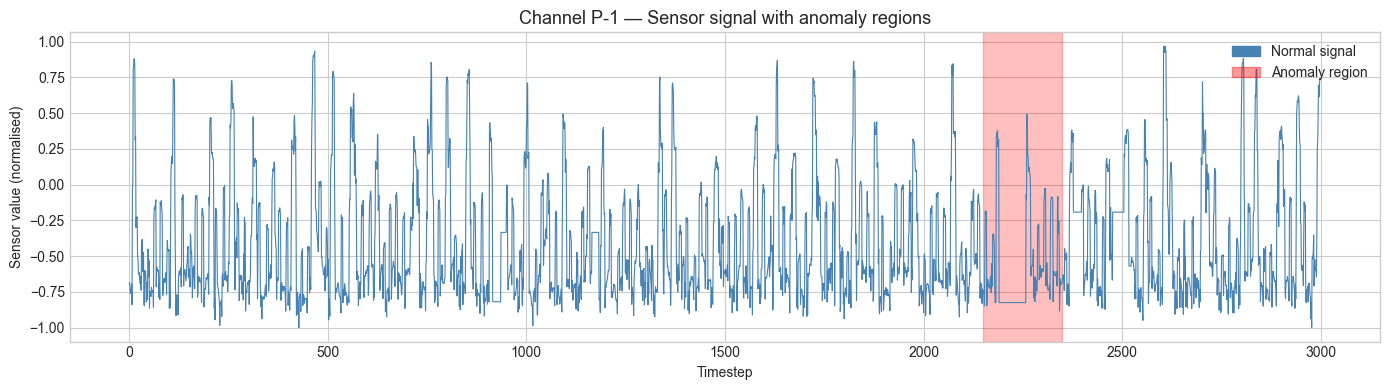

✅ Plot saved


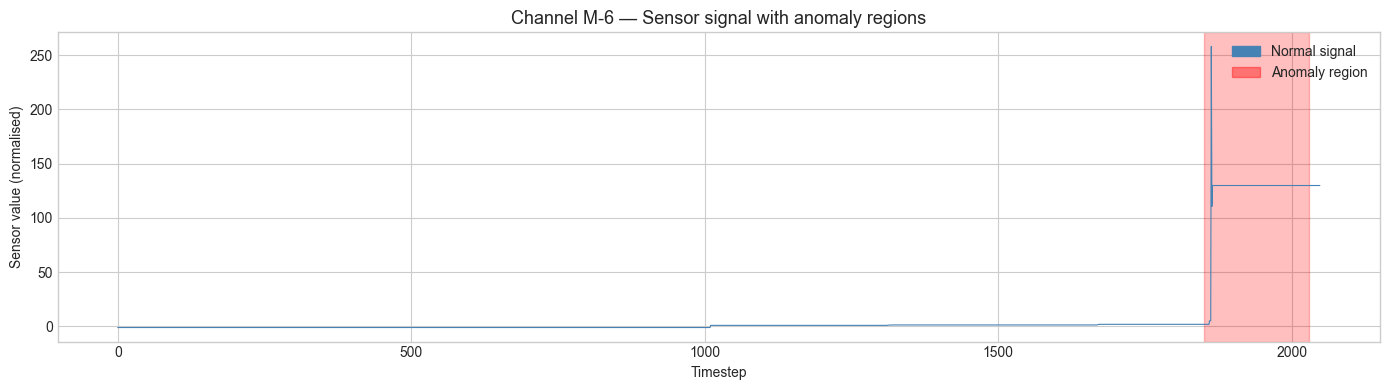

✅ Plot saved


In [7]:
def get_anomaly_ranges(channel_id):
    ch_df  = labels_df[labels_df['chan_id'] == channel_id]
    ranges = []
    for _, row in ch_df.iterrows():
        for seq in eval(row['anomaly_sequences']):
            ranges.append((seq[0], seq[1]))
    return ranges

def plot_channel(channel_id, max_points=3000):
    test_data = load_channel(channel_id, 'test')
    signal    = test_data[:max_points, 0]
    time      = np.arange(len(signal))

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(time, signal, color='steelblue', linewidth=0.8)

    for start, end in get_anomaly_ranges(channel_id):
        if start < max_points:
            ax.axvspan(start, min(end, max_points),
                       alpha=0.25, color='red')

    handles = [
        mpatches.Patch(color='steelblue', label='Normal signal'),
        mpatches.Patch(color='red', alpha=0.4, label='Anomaly region')
    ]
    ax.legend(handles=handles, loc='upper right', fontsize=10)
    ax.set_title(f"Channel {channel_id} — Sensor signal with anomaly regions",
                 fontsize=13)
    ax.set_xlabel("Timestep")
    ax.set_ylabel("Sensor value (normalised)")
    plt.tight_layout()
    plt.savefig(f"results/figures/channel_{channel_id}.png", dpi=150)
    plt.show()
    print(f"✅ Plot saved")

os.makedirs("results/figures", exist_ok=True)

# Plot first SMAP and first MSL channel
plot_channel(smap_channels[0])
plot_channel(msl_channels[0])

ANOMALY STATISTICS BY SPACECRAFT
            total_points  anomaly_points  avg_anom_pct  total_anom_seqs
spacecraft                                                             
MSL                73729            7730         11.97               36
SMAP              444035           56974         12.43               69

Overall anomaly percentage : 12.28%

--- This proves the label scarcity problem ---
Only 12.3% of data is anomalous.
A standard supervised model cannot learn from this.
This is exactly why few-shot meta-learning is needed.


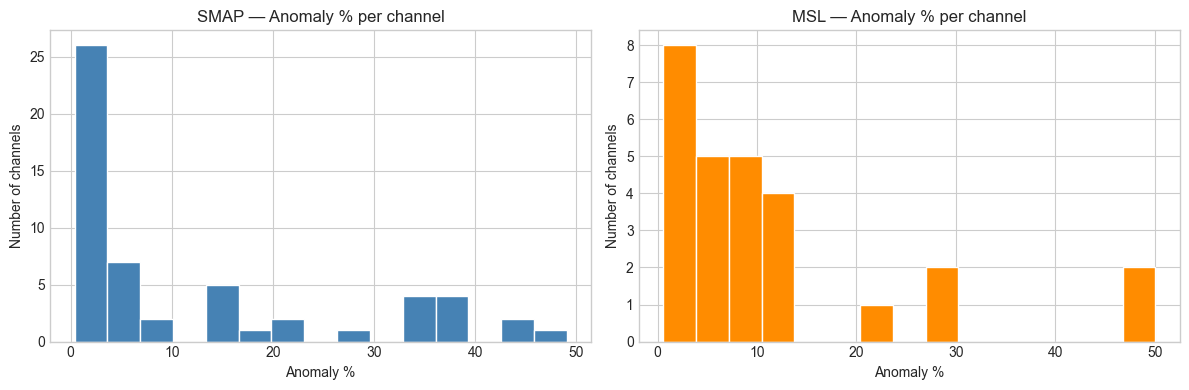

✅ Plot saved


In [8]:
anomaly_stats = []

for _, row in labels_df.iterrows():
    ch           = row['chan_id']
    test         = load_channel(ch, 'test')
    total        = test.shape[0]
    mask         = np.zeros(total, dtype=bool)

    for seq in eval(row['anomaly_sequences']):
        mask[int(seq[0]):min(int(seq[1]), total)] = True

    anom_pts = mask.sum()
    anomaly_stats.append({
        'channel'         : ch,
        'spacecraft'      : row['spacecraft'],
        'total_points'    : total,
        'anomaly_points'  : int(anom_pts),
        'anomaly_percent' : round((anom_pts / total) * 100, 2),
        'n_anomaly_seqs'  : len(eval(row['anomaly_sequences']))
    })

anom_df = pd.DataFrame(anomaly_stats)

print("=" * 55)
print("ANOMALY STATISTICS BY SPACECRAFT")
print("=" * 55)
print(anom_df.groupby('spacecraft').agg(
    total_points    = ('total_points','sum'),
    anomaly_points  = ('anomaly_points','sum'),
    avg_anom_pct    = ('anomaly_percent','mean'),
    total_anom_seqs = ('n_anomaly_seqs','sum')
).round(2))

print(f"\nOverall anomaly percentage : {anom_df['anomaly_percent'].mean():.2f}%")
print(f"\n--- This proves the label scarcity problem ---")
print(f"Only {anom_df['anomaly_percent'].mean():.1f}% of data is anomalous.")
print(f"A standard supervised model cannot learn from this.")
print(f"This is exactly why few-shot meta-learning is needed.")

# Plot anomaly % distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, spacecraft, color in zip(
        axes, ['SMAP','MSL'], ['steelblue','darkorange']):
    data = anom_df[anom_df['spacecraft']==spacecraft]['anomaly_percent']
    ax.hist(data, bins=15, color=color, edgecolor='white')
    ax.set_title(f'{spacecraft} — Anomaly % per channel')
    ax.set_xlabel('Anomaly %')
    ax.set_ylabel('Number of channels')
plt.tight_layout()
plt.savefig("results/figures/anomaly_distribution.png", dpi=150)
plt.show()
print("✅ Plot saved")

In [9]:
print("=" * 55)
print("MAML TASK STRUCTURE ANALYSIS")
print("=" * 55)

seq_counts = labels_df.copy()
seq_counts['n_seqs'] = seq_counts['anomaly_sequences'].apply(
    lambda x: len(eval(x)))

smap_tasks = seq_counts[seq_counts['spacecraft']=='SMAP']
msl_tasks  = seq_counts[seq_counts['spacecraft']=='MSL']

print(f"\nTotal MAML tasks         : {len(seq_counts)}")
print(f"SMAP tasks               : {len(smap_tasks)}")
print(f"MSL  tasks               : {len(msl_tasks)}")

print(f"\nAnomaly sequences per channel:")
print(seq_counts.groupby('spacecraft')['n_seqs'].describe().round(2))

# Shot-condition feasibility
for k in [1, 5, 10]:
    suitable = seq_counts[seq_counts['n_seqs'] >= k]
    smap_ok  = len(suitable[suitable['spacecraft']=='SMAP'])
    msl_ok   = len(suitable[suitable['spacecraft']=='MSL'])
    print(f"\n{k}-shot: {len(suitable)} tasks suitable "
          f"(SMAP: {smap_ok}, MSL: {msl_ok})")

print(f"\n--- What This Means For Training ---")
print(f"Each channel = 1 MAML task")
print(f"Support set  = K anomaly examples from that channel")
print(f"Query set    = remaining anomaly + normal examples")
print(f"Outer loop   = updates shared meta-initialization θ*")
print(f"Inner loop   = adapts θ* to each task in K steps")

MAML TASK STRUCTURE ANALYSIS

Total MAML tasks         : 82
SMAP tasks               : 55
MSL  tasks               : 27

Anomaly sequences per channel:
            count  mean   std  min  25%  50%  75%  max
spacecraft                                            
MSL          27.0  1.33  0.55  1.0  1.0  1.0  2.0  3.0
SMAP         55.0  1.25  0.58  1.0  1.0  1.0  1.0  3.0

1-shot: 82 tasks suitable (SMAP: 55, MSL: 27)

5-shot: 0 tasks suitable (SMAP: 0, MSL: 0)

10-shot: 0 tasks suitable (SMAP: 0, MSL: 0)

--- What This Means For Training ---
Each channel = 1 MAML task
Support set  = K anomaly examples from that channel
Query set    = remaining anomaly + normal examples
Outer loop   = updates shared meta-initialization θ*
Inner loop   = adapts θ* to each task in K steps
